# Details of an Exoplanet in orbit in the 55 Cancri system 
### By Timothy Koehler

In [1]:
import os 
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
from scipy import optimize

In [2]:
os.getcwd()#get current directory 

'C:\\Users\\timko'

In [3]:
fname = 'C:\\Users\\timko\\Pdata.dat'#name data set 

In [4]:
tab = Table.read(fname,format='ascii') #Read data table from Nasa site

In [5]:
x = tab["HJD"] #Define variables from table 
y = tab["Radial_Velocity"]
z = tab["Radial_Velocity_Uncertainty"]
yerror = z #define error variable 

## Plot of the radial velocity(m/s) of the exoplanet compared to time(days)

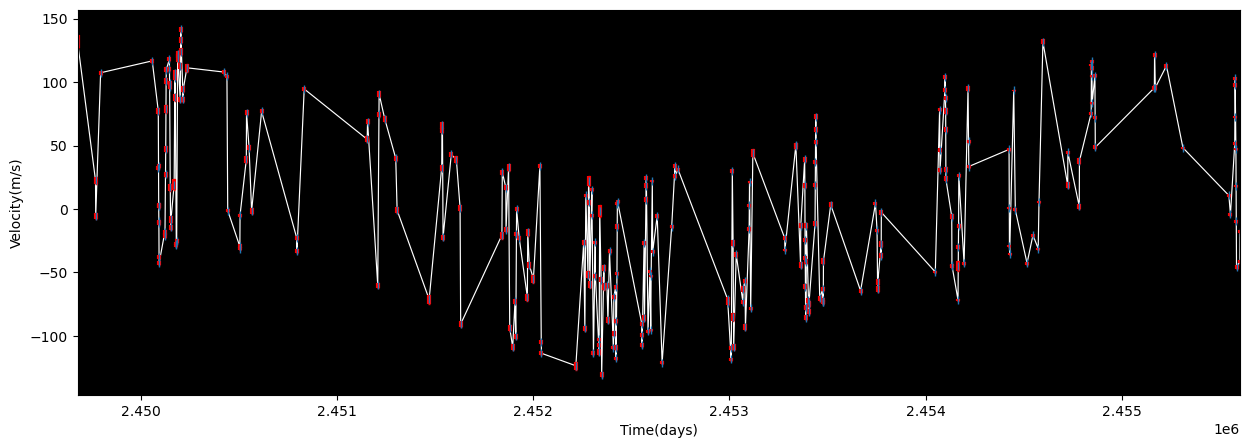

In [6]:
plt.figure(figsize=(15,5))#adjust fig size 
ax = plt.gca() #change background color
ax.set_facecolor("black")
plt.plot(x,y, color="white", linewidth=.85)#plot velocities as a function of time
plt.xlabel("Time(days)")#label axes
plt.ylabel("Velocity(m/s)")
plt.xlim(2449676.0632,2455603.80404)#limit x axis 
plt.errorbar(x,y, xerr=0, yerr=yerror, elinewidth=3, capsize=1, fmt='|', ecolor="red")#show error on plot 
plt.show()

##  occilitory function describing uncertainty of the radial velocity

In [7]:
def y_func(x,a,b,c):#define posible occilitory function 
    return a*np.sin(2*np.pi*(x-c)/b)

In [8]:
p0 = [150, 5000, 4000] #range of posible optimization for variables 
popt = optimize.curve_fit(y_func,x,y,p0)#find variables of best fit 
print(f"The amplitude of the regression line is: {popt[0][0]:.4f} \nThe period of the regression line is: {popt[0][1]:.4f} \nThe displacement of the regression line is: {popt[0][2]:.4f}")

The amplitude of the regression line is: 54.4008 
The period of the regression line is: 4774.4431 
The displacement of the regression line is: 114387.1447


In [9]:
prediction = y_func(x, *popt[0]) #regression line values

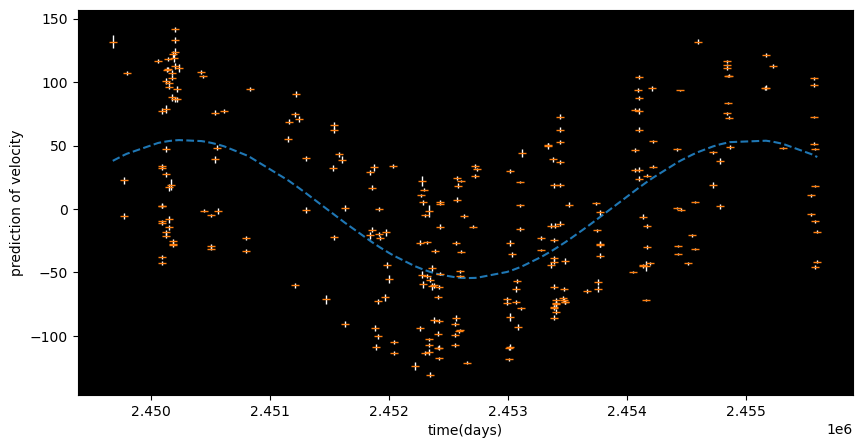

In [10]:
plt.figure(figsize=(10,5))#set fig size 
ax = plt.gca()#set background color 
ax.set_facecolor("black")
plt.plot(x,prediction, ls='--')#plot regression line 
plt.xlabel("time(days)")#label axes 
plt.ylabel("prediction of velocity")
plt.errorbar(x,y, xerr=0, yerr=yerror, elinewidth=1, capsize=.1, capthick=.1, fmt='_', ecolor="white") #show error bars 
plt.show()

### Histrogram of data error

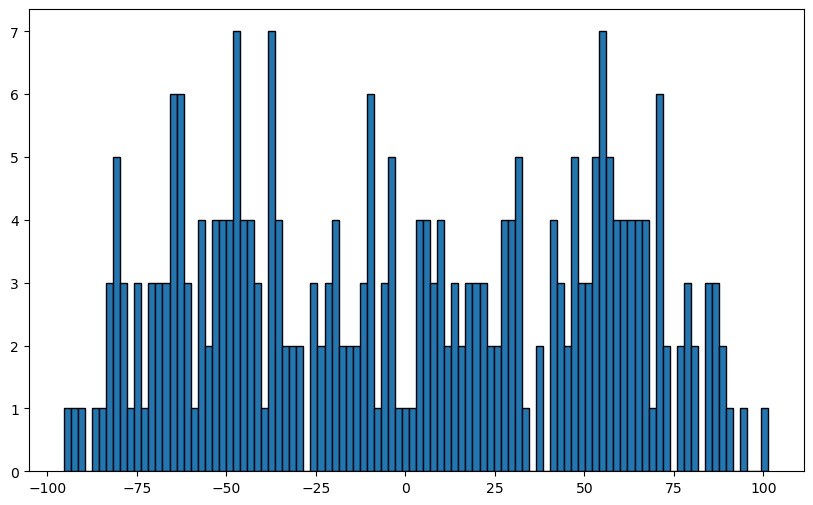

In [11]:
plt.figure(figsize=(10,6))#set fig size
q = y-prediction #subtract observed from expected 
plt.hist(q, bins=100, edgecolor="black") #plot histogram of errors 
xlabel=("Velocity Data Error")#label axes 
ylabel=("frequency of a certain amount of error") 

### Calculation of the mass of the exoplanet 

In [12]:
k = popt[0][0] #define amplitude 
p = popt[0][1] #define period 
m0 = .9 #sun's mass 
m = ((k/28.4)*((p/365)**(1/3)))*m0 #calculate mass of exoplanet 
print(f"The mass of the Exoplanet is: {m:.7f}")

The mass of the Exoplanet is: 4.0619940
